In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [30]:
data=pd.read_csv('train_FD002.txt')

In [31]:
data.head()

,1 1 34.9983 0.8400 100.0 449.44 555.32 1358.61 1137.23 5.48 8.00 194.64 2222.65 8341.91 1.02 42.02 183.06 2387.72 8048.56 9.3461 0.02 334 2223 100.00 14.73 8.8071
0,1 2 41.9982 0.8408 100.0 445.00 549.90 1353.22...
1,1 3 24.9988 0.6218 60.0 462.54 537.31 1256.76 ...
2,1 4 42.0077 0.8416 100.0 445.00 549.51 1354.03...
3,1 5 25.0005 0.6203 60.0 462.54 537.07 1257.71 ...
4,1 6 25.0045 0.6205 60.0 462.54 537.02 1266.38 ...


In [32]:
index_names = ['unit_number', 'time_in_cycles']
setting_names = ['setting1', 'setting2', 'setting3']
sensor_names = ['sensor{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

data = pd.read_csv('train_FD002.txt', sep='\s+', header=None, names=col_names)


print(data.shape)

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\HP\AppData\Local\Temp\ipykernel_24472\2759536201.py:6: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv('train_FD002.txt', sep='\s+', header=None, names=col_names)


(53759, 26)


In [33]:

# data.to_excel('train_FD002_data.xlsx', index=False)

# from google.colab import files
# files.download('train_FD002_data.xlsx')



In [34]:
data.head()

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286


In [35]:
# from google.colab import files
# files.download('train_FD001.csv')

In [36]:
data.duplicated().sum()

np.int64(0)

In [37]:
data.nunique()

unit_number         260
time_in_cycles      378
setting1            536
setting2            105
setting3              2
sensor1               6
sensor2            1590
sensor3           12305
sensor4           15411
sensor5               6
sensor6              14
sensor7            2067
sensor8             897
sensor9           22434
sensor10              9
sensor11            681
sensor12           1672
sensor13            514
sensor14          14905
sensor15           8464
sensor16              2
sensor17             53
sensor18              6
sensor19              2
sensor20            510
sensor21          17837
dtype: int64

In [38]:
max_cycle = data.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_life']
data=data.merge(max_cycle, on='unit_number', how='left')
data['RUL'] = data['max_life'] - data['time_in_cycles']
data.drop('max_life', axis=1, inplace=True)
data[['unit_number', 'time_in_cycles', 'RUL']].head()

,unit_number,time_in_cycles,RUL
0,1,1,148
1,1,2,147
2,1,3,146
3,1,4,145
4,1,5,144


In [39]:
data["RUL"] = data["RUL"].clip(upper=125) #عشان بيتعب من اول الايام 125 بتظهر عليه الاعراض

In [40]:
for column in data.columns:
  print(column,":",data[column].nunique())


unit_number : 260
time_in_cycles : 378
setting1 : 536
setting2 : 105
setting3 : 2
sensor1 : 6
sensor2 : 1590
sensor3 : 12305
sensor4 : 15411
sensor5 : 6
sensor6 : 14
sensor7 : 2067
sensor8 : 897


sensor9 : 22434
sensor10 : 9
sensor11 : 681
sensor12 : 1672
sensor13 : 514
sensor14 : 14905
sensor15 : 8464
sensor16 : 2
sensor17 : 53
sensor18 : 6
sensor19 : 2
sensor20 : 510
sensor21 : 17837
RUL : 126


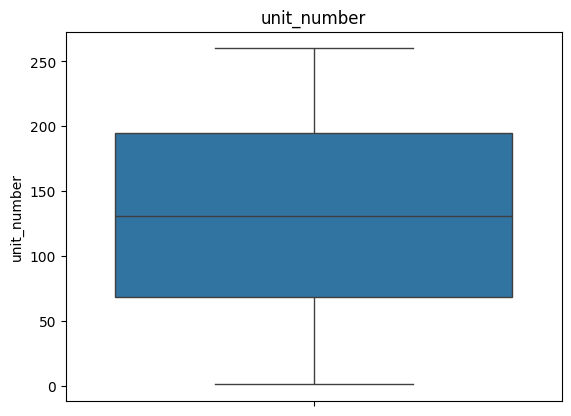

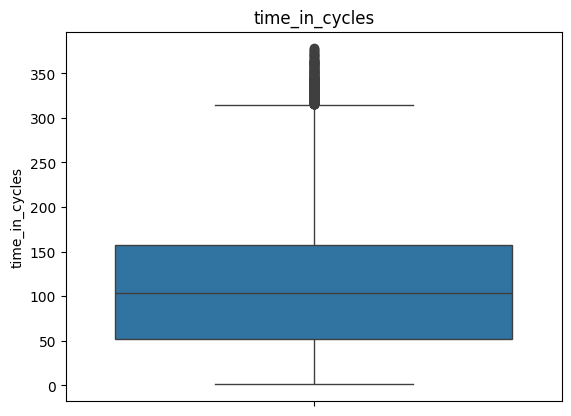

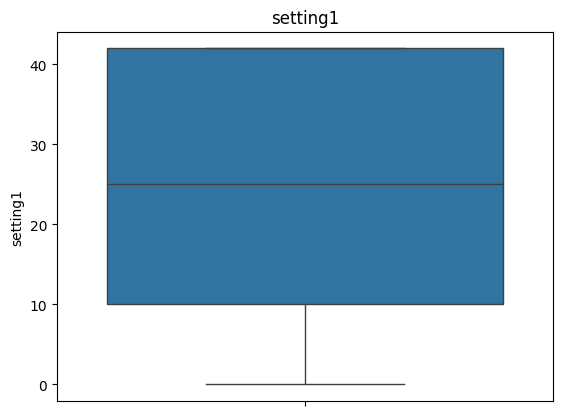

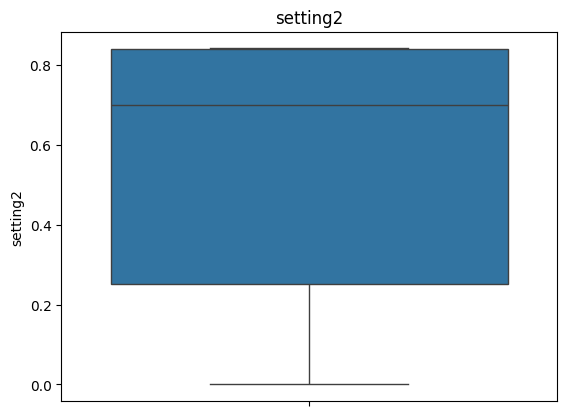

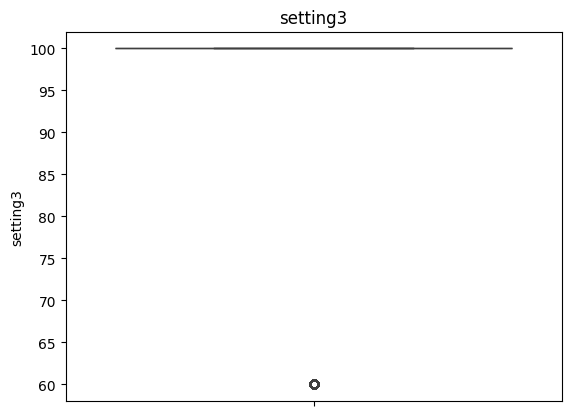

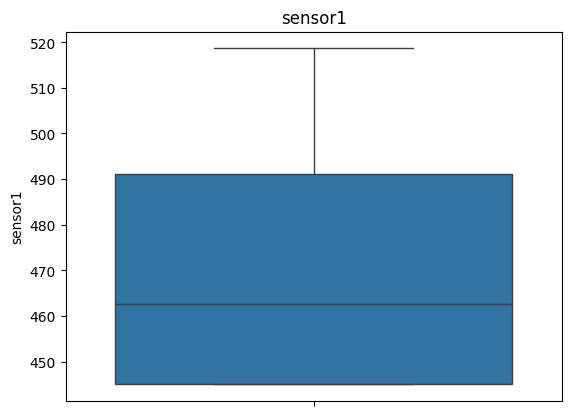

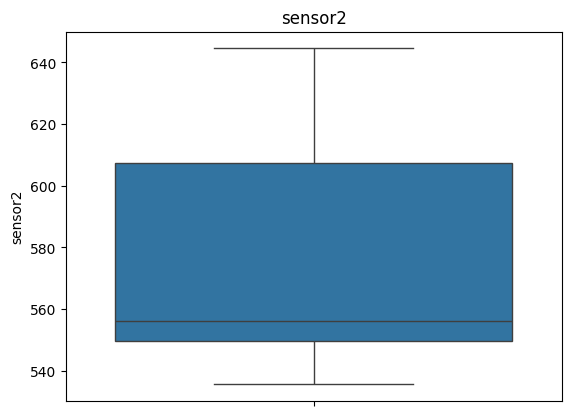

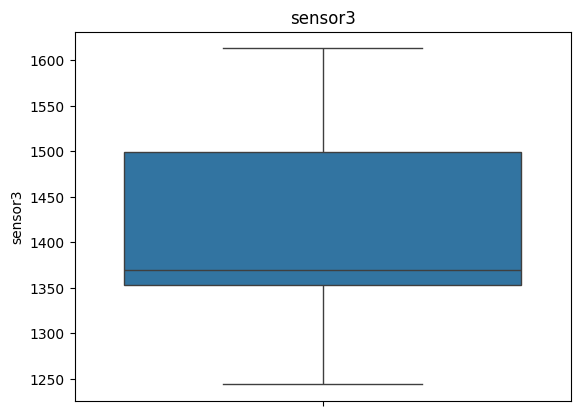

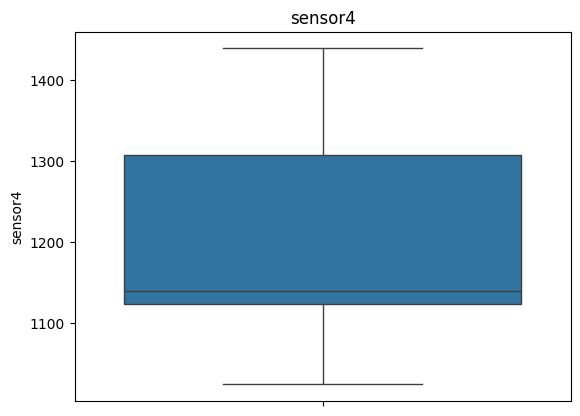

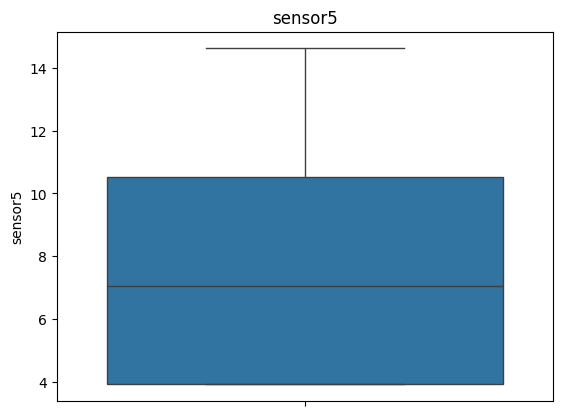

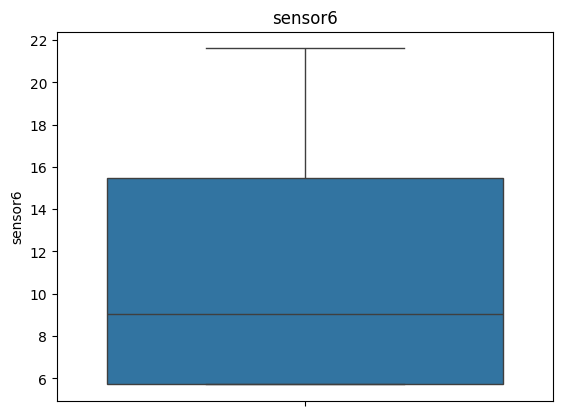

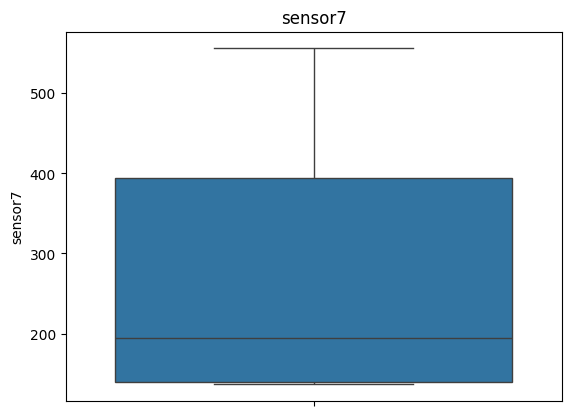

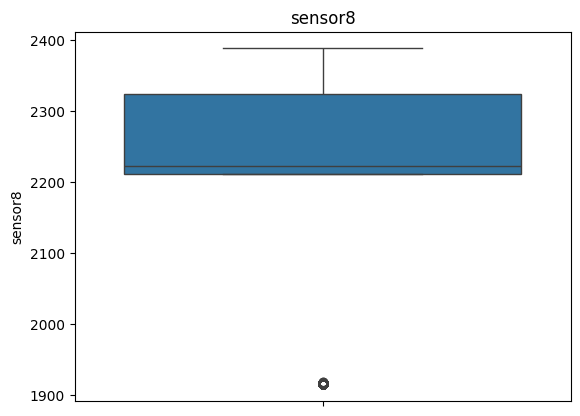

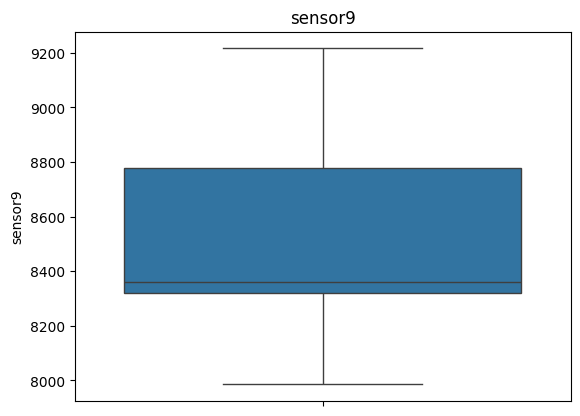

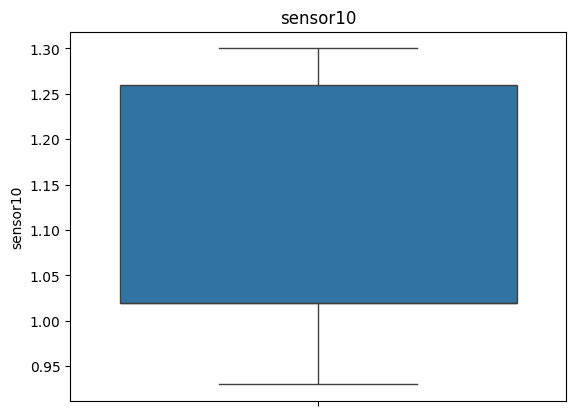

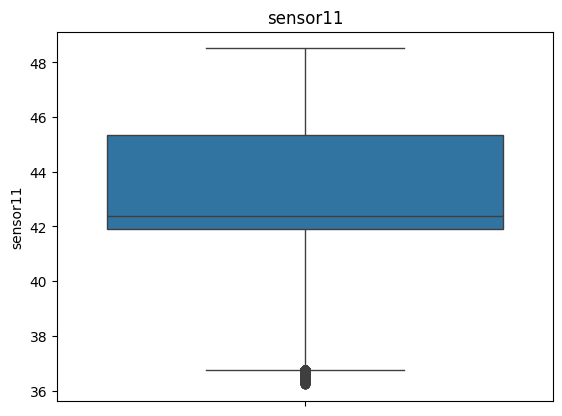

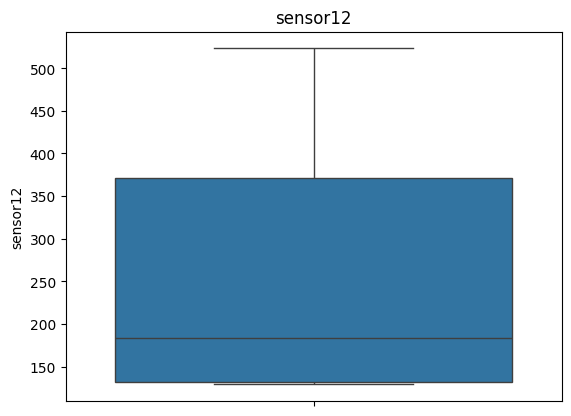

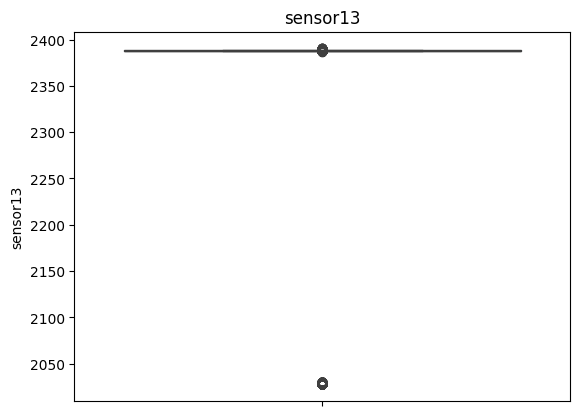

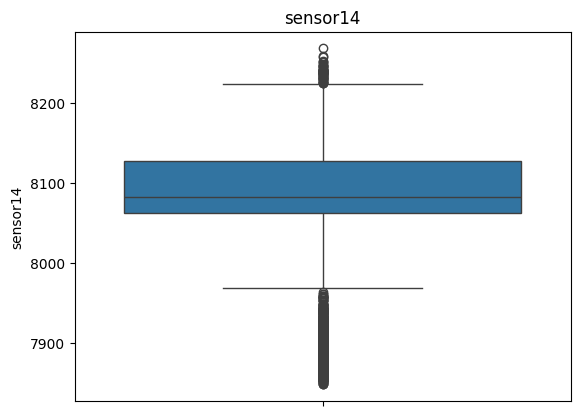

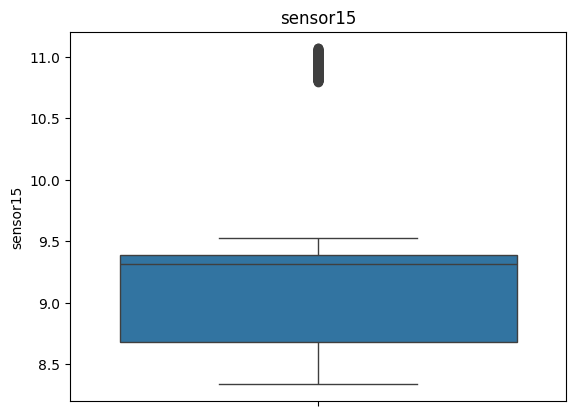

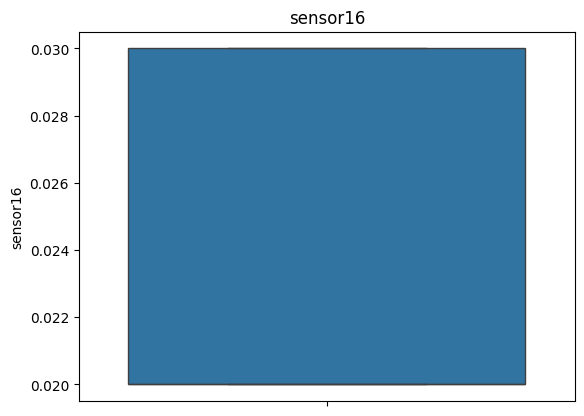

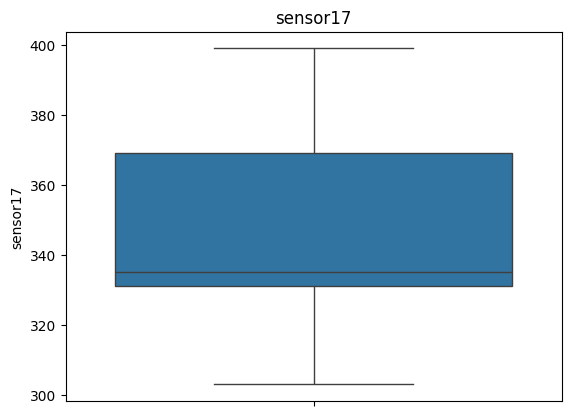

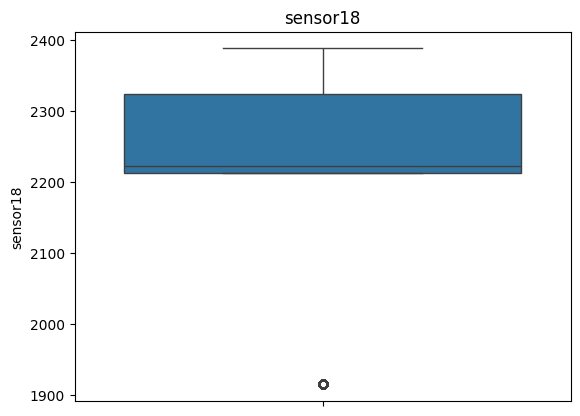

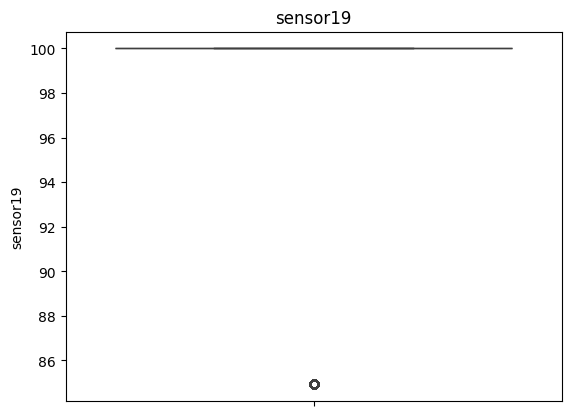

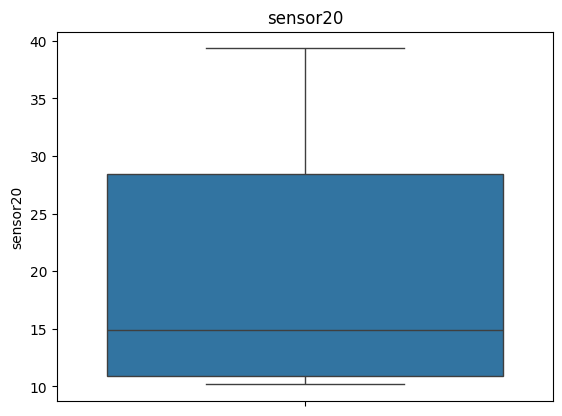

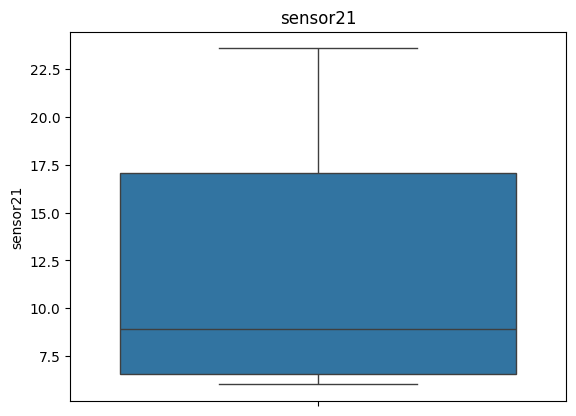

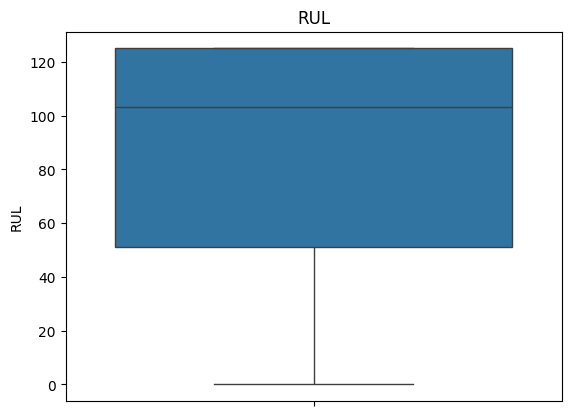

In [41]:
for i in data:
  sns.boxplot(data[i])
  plt.title(i)
  plt.show()

In [42]:
data.columns

Index(['unit_number', 'time_in_cycles', 'setting1', 'setting2', 'setting3',
       'sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6',
       'sensor7', 'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12',
       'sensor13', 'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18',
       'sensor19', 'sensor20', 'sensor21', 'RUL'],
      dtype='object')

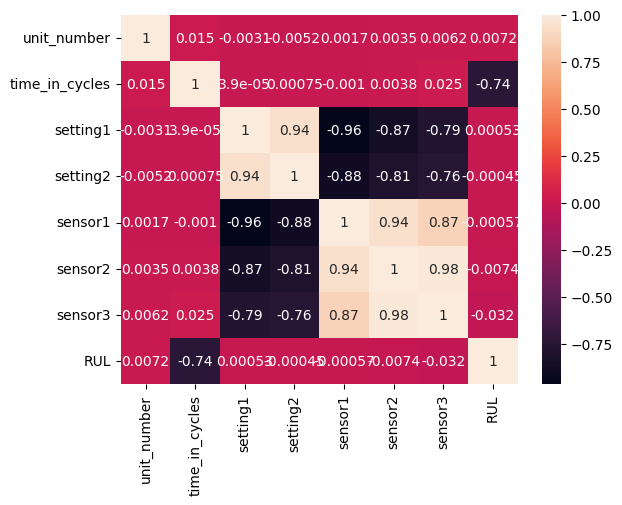

In [43]:
cols=['unit_number', 'time_in_cycles', 'setting1', 'setting2',
       'sensor1', 'sensor2', 'sensor3', 'RUL']
corr=data[cols].corr()
sns.heatmap(corr,annot=True)
plt.show()

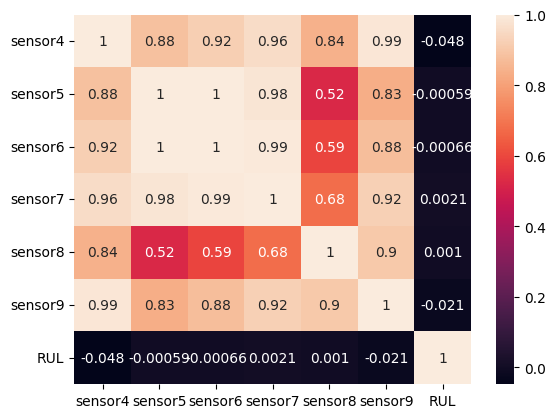

In [44]:
cols2=['sensor4', 'sensor5', 'sensor6',
       'sensor7', 'sensor8', 'sensor9',  'RUL']
corr=data[cols2].corr()
sns.heatmap(corr,annot=True)
plt.show()

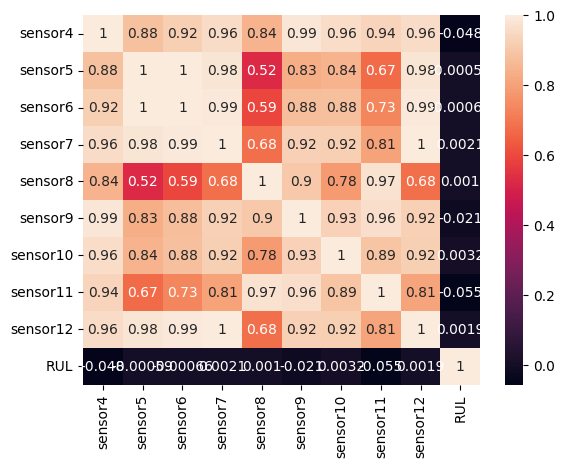

In [45]:
cols2=['sensor4', 'sensor5', 'sensor6',
       'sensor7', 'sensor8', 'sensor9','sensor10', 'sensor11', 'sensor12',  'RUL']
corr=data[cols2].corr()
sns.heatmap(corr,annot=True)
plt.show()

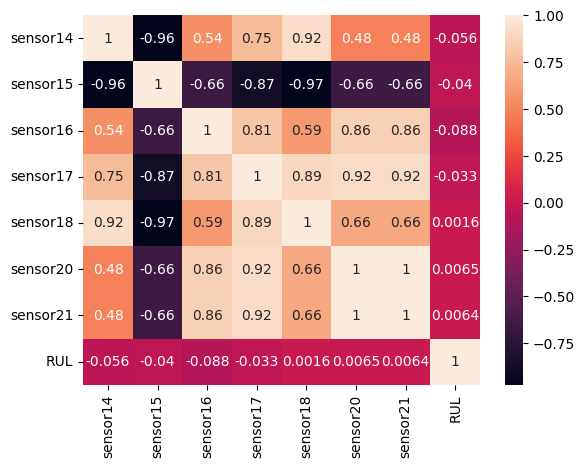

In [46]:
cols3=['sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18',
        'sensor20', 'sensor21', 'RUL']
corr=data[cols3].corr()
sns.heatmap(corr,annot=True)
plt.show()

In [47]:
data.describe()

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,RUL
count,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,...,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000
mean,131.082981,109.154746,23.998407,0.572056,94.046020,472.910207,579.672399,1419.971013,1205.442024,8.031986,...,2334.557253,8066.597682,9.329654,0.023326,348.309511,2228.806358,97.756838,20.789296,12.473423,86.913354
std,74.463862,69.180569,14.747376,0.310016,14.237735,26.389707,37.289399,105.946341,119.123428,3.613839,...,128.068271,84.837950,0.749335,0.004711,27.754515,145.327980,5.364067,9.869331,5.921615,41.665602
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.530000,1243.730000,1023.770000,3.910000,...,2027.610000,7848.360000,8.335700,0.020000,303.000000,1915.000000,84.930000,10.180000,6.010500,0.000000
25%,68.000000,52.000000,10.004600,0.250700,100.000000,445.000000,549.570000,1352.760000,1123.655000,3.910000,...,2387.900000,8062.140000,8.677800,0.020000,331.000000,2212.000000,100.000000,10.910000,6.546300,51.000000
50%,131.000000,104.000000,25.001300,0.700000,100.000000,462.540000,555.980000,1369.180000,1138.890000,7.050000,...,2388.080000,8082.540000,9.310900,0.020000,335.000000,2223.000000,100.000000,14.880000,8.929200,103.000000
75%,195.000000,157.000000,41.998000,0.840000,100.000000,491.190000,607.340000,1499.370000,1306.850000,10.520000,...,2388.170000,8127.195000,9.386900,0.030000,369.000000,2324.000000,100.000000,28.470000,17.083200,125.000000
max,260.000000,378.000000,42.008000,0.842000,100.000000,518.670000,644.520000,1612.880000,1439.230000,14.620000,...,2390.480000,8268.500000,11.066900,0.030000,399.000000,2388.000000,100.000000,39.340000,23.590100,125.000000


In [48]:
from pandas.core.window.rolling import Window
window=5
for col in data.columns:
    if col not in ["unit_number", "time_in_cycles", "RUL"]:
        data[col + "_mean"] = data.groupby("unit_number")[col].transform(lambda x: x.rolling(window).mean())
        data[col + "_std"] = data.groupby("unit_number")[col].transform(lambda x: x.rolling(window).std())

In [49]:
data = data.bfill()

In [ ]:
features=sensor_names+setting_names
final_features = features + [col + '_mean' for col in features] + [col + '_std' for col in features]

In [ ]:
scaler = StandardScaler()
data[final_features] = scaler.fit_transform(data[final_features])
X = data[final_features]
y = data['RUL']

In [ ]:
print(X.columns.tolist())

['sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19', 'sensor20', 'sensor21', 'setting1', 'setting2', 'setting3', 'sensor1_mean', 'sensor2_mean', 'sensor3_mean', 'sensor4_mean', 'sensor5_mean', 'sensor6_mean', 'sensor7_mean', 'sensor8_mean', 'sensor9_mean', 'sensor10_mean', 'sensor11_mean', 'sensor12_mean', 'sensor13_mean', 'sensor14_mean', 'sensor15_mean', 'sensor16_mean', 'sensor17_mean', 'sensor18_mean', 'sensor19_mean', 'sensor20_mean', 'sensor21_mean', 'setting1_mean', 'setting2_mean', 'setting3_mean', 'sensor1_std', 'sensor2_std', 'sensor3_std', 'sensor4_std', 'sensor5_std', 'sensor6_std', 'sensor7_std', 'sensor8_std', 'sensor9_std', 'sensor10_std', 'sensor11_std', 'sensor12_std', 'sensor13_std', 'sensor14_std', 'sensor15_std', 'sensor16_std', 'sensor17_std', 'sensor18_std', 'sensor19_std', 'sensor20_std', 'sensor21_

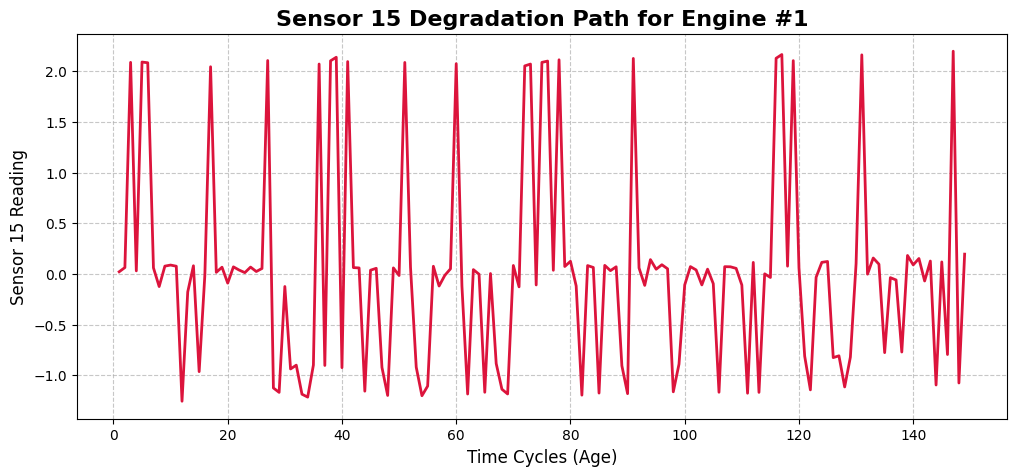

In [ ]:
# بنفلتر الداتا عشان نجيب المحرك رقم 1 بس
engine_1_data = data[data['unit_number'] == 1]

plt.figure(figsize=(12, 5))
# بنرسم العلاقة بين الدورات (الوقت) وقراءة الحساس
sns.lineplot(data=engine_1_data, x='time_in_cycles', y='sensor15', color='crimson', linewidth=2)

plt.title('Sensor 15 Degradation Path for Engine #1', fontsize=16, fontweight='bold')
plt.xlabel('Time Cycles (Age)', fontsize=12)
plt.ylabel('Sensor 15 Reading', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = data['unit_number']

for train_idx, test_idx in gss.split(X, y, groups):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

settings_cols = ['setting1', 'setting2', 'setting3']

X_train['cluster'] = kmeans.fit_predict(X_train[settings_cols])
X_test['cluster'] = kmeans.predict(X_test[settings_cols])

X_train = pd.get_dummies(X_train, columns=['cluster'], prefix='Condition')
X_test = pd.get_dummies(X_test, columns=['cluster'], prefix='Condition')

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

xgb_boss = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_boss.fit(X_train, y_train)

y_train_pred = xgb_boss.predict(X_train)
y_test_pred = xgb_boss.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("-" * 35)
print(f" Train RMSE: {rmse_train:.2f}")
print(f" Test RMSE:  {rmse_test:.2f}")
print("-" * 35)
print(f" Train R2: {r2_train*100:.2f}%")
print(f" Test R2:  {r2_test*100:.2f}%")
print("-" * 35)

-----------------------------------
 Train RMSE: 14.57
 Test RMSE:  19.64
-----------------------------------
 Train R2: 87.75%
 Test R2:  77.92%
-----------------------------------


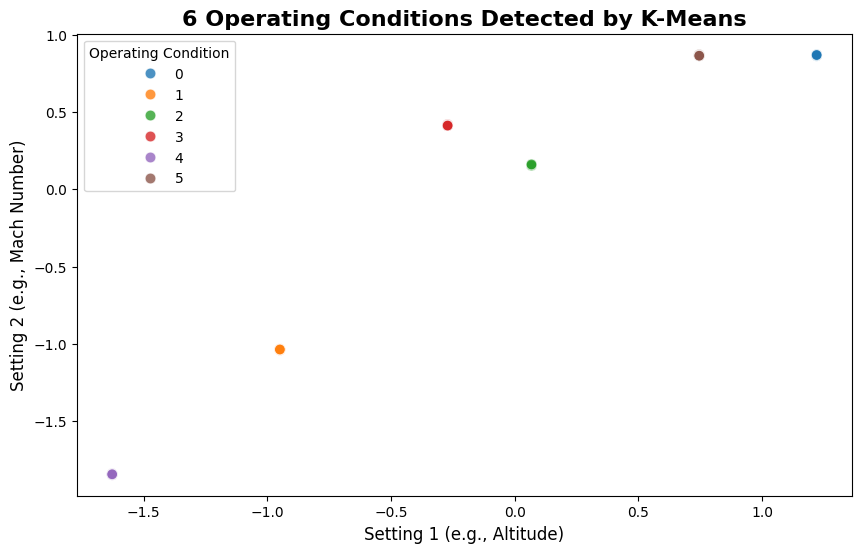

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. بنعمل نسخة مؤقتة للرسم عشان منبوظش داتا التدريب
plot_data = X_train.copy()

# 2. بنخلي الـ K-Means يتوقع الكلاسترز ونحطها في عمود جديد اسمه 'cluster'
settings_cols = ['setting1', 'setting2', 'setting3']
plot_data['cluster'] = kmeans.predict(plot_data[settings_cols])

# 3. الرسمة الجميلة بتاعتك (دلوقتي هتشتغل لأن العمود بقى موجود)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, x='setting1', y='setting2', hue='cluster', palette='tab10', s=60, alpha=0.8)

plt.title('6 Operating Conditions Detected by K-Means', fontsize=16, fontweight='bold')
plt.xlabel('Setting 1 (e.g., Altitude)', fontsize=12)
plt.ylabel('Setting 2 (e.g., Mach Number)', fontsize=12)

plt.legend(title='Operating Condition')
plt.show()

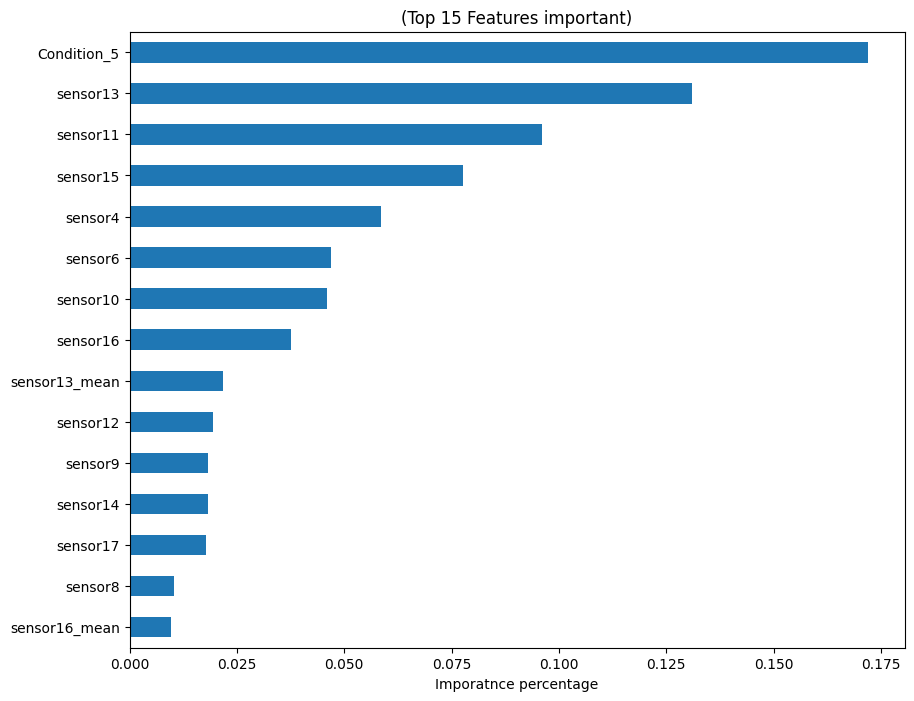

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

feat_importances = pd.Series(xgb_boss.feature_importances_, index=X_test.columns)

plt.figure(figsize=(10, 8))


feat_importances.nlargest(15).sort_values().plot(kind='barh')

plt.title('(Top 15 Features important)')
plt.xlabel('Imporatnce percentage')
plt.show()

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# rf_model_fd002 = RandomForestRegressor(n_estimators=150,max_depth=15,
#     min_samples_split=10,min_samples_leaf=4,max_features='sqrt', random_state=42, n_jobs=-1)

# rf_model_fd002.fit(X_train, y_train)

# y_train_pred = rf_model_fd002.predict(X_train)
# y_test_pred = rf_model_fd002.predict(X_test)


# rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
# rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# r2_train = r2_score(y_train, y_train_pred)
# r2_test = r2_score(y_test, y_test_pred)


# print(f"Train RMSE: {rmse_train:.2f}")
# print(f"Test RMSE:  {rmse_test:.2f}")

# print(f"Train Accuracy (R2): {r2_train*100:.2f}%")
# print(f"Test Accuracy (R2):  {r2_test*100:.2f}%")


In [ ]:
# from xgboost import XGBRegressor
# from sklearn.metrics import mean_squared_error, r2_score
# import numpy as np

# xgb_boss = XGBRegressor(n_estimators=400,learning_rate=0.05,max_depth=7,subsample=0.8,colsample_bytree=0.8,random_state=42,n_jobs=-1)

# xgb_boss.fit(X_train, y_train)


# y_train_pred_xgb = xgb_boss.predict(X_train)
# y_test_pred_xgb = xgb_boss.predict(X_test)


# rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
# rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))

# r2_train_xgb = r2_score(y_train, y_train_pred_xgb)
# r2_test_xgb = r2_score(y_test, y_test_pred_xgb)

# print(f" XGB Train RMSE: {rmse_train_xgb:.2f}")
# print(f" XGB Test RMSE:  {rmse_test_xgb:.2f}")
# print(f" XGB Train Accuracy (R2): {r2_train_xgb*100:.2f}%")
# print(f" XGB Test Accuracy (R2):  {r2_test_xgb*100:.2f}%")


In [62]:
test_data2 = pd.read_csv(r'test_FD002.txt', sep='\s+', header=None)
test_data2.dropna(axis=1, how='all', inplace=True)
test_data2.columns = col_names
from pandas.core.window.rolling import Window

window = 5
for col in features:
    test_data2[col + '_mean'] = test_data2.groupby('unit_number')[col].transform(lambda x: x.rolling(window).mean())
    test_data2[col + '_std'] = test_data2.groupby('unit_number')[col].transform(lambda x: x.rolling(window).std())

test_data2 = test_data2.bfill()

test_last = test_data2.groupby('unit_number').last().reset_index()

test_last[final_features] = scaler.transform(test_last[final_features])

settings_cols = ['setting1', 'setting2', 'setting3']
test_clusters = kmeans.predict(test_last[settings_cols])

for i in range(6):
    test_last[f'Condition_{i}'] = (test_clusters == i).astype(int)

X_final_test = test_last[X_train.columns]

true_rul2 = pd.read_csv(r'RUL_FD002.txt', sep='\s+', header=None).iloc[:, 0]
true_rul2_clipped = true_rul2.clip(upper=125)

final_predictions = xgb_boss.predict(X_final_test)

final_rmse = np.sqrt(mean_squared_error(true_rul2_clipped, final_predictions))
final_r2 = r2_score(true_rul2_clipped, final_predictions)

print("=" * 40)
print(f" FINAL EXAM RMSE: {final_rmse:.2f}")
print(f" FINAL EXAM R2 SCORE: {final_r2 * 100:.2f}%")
print("=" * 40)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
C:\Users\HP\AppData\Local\Temp\ipykernel_24472\3405806831.py:1: SyntaxWarning: invalid escape sequence '\s'
  test_data2 = pd.read_csv(r'test_FD002.txt', sep='\s+', header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_24472\3405806831.py:25: SyntaxWarning: invalid escape sequence '\s'
  true_rul2 = pd.read_csv(r'RUL_FD002.txt', sep='\s+', header=None).iloc[:, 0]


 FINAL EXAM RMSE: 16.99
 FINAL EXAM R2 SCORE: 84.35%


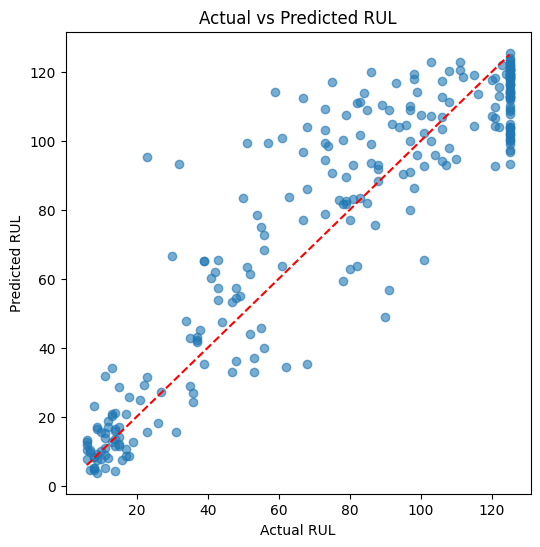

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(true_rul2_clipped, final_predictions, alpha=0.6)

plt.plot([true_rul2_clipped.min(), true_rul2_clipped.max()],
         [true_rul2_clipped.min(), true_rul2_clipped.max()],
         'r--')

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

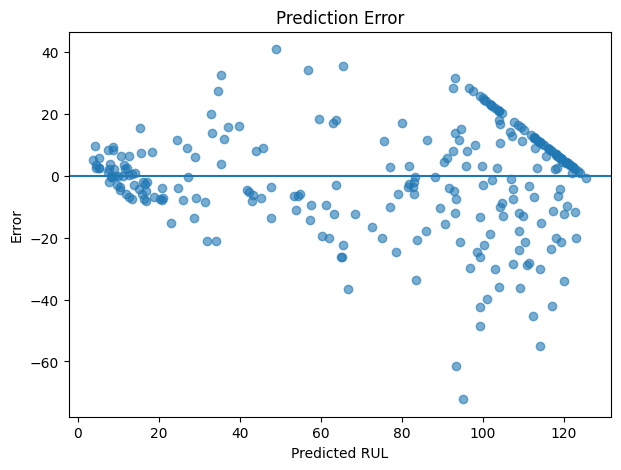

In [64]:
error = true_rul2_clipped - final_predictions


plt.figure(figsize=(7,5))
plt.scatter(final_predictions, error, alpha=0.6)

plt.axhline(0)

plt.xlabel("Predicted RUL")
plt.ylabel("Error")
plt.title("Prediction Error")

plt.show()

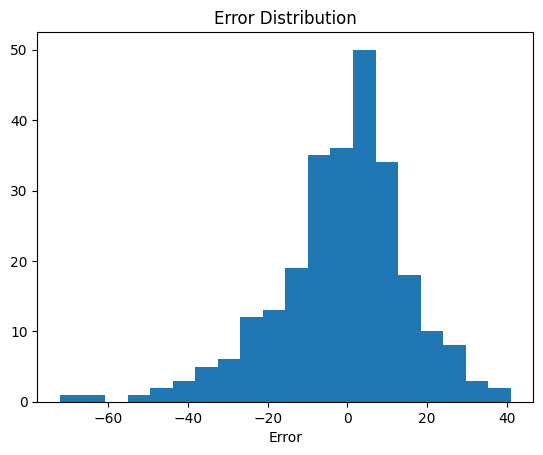

In [65]:
plt.hist(error, bins=20)

plt.xlabel("Error")
plt.title("Error Distribution")

plt.show()


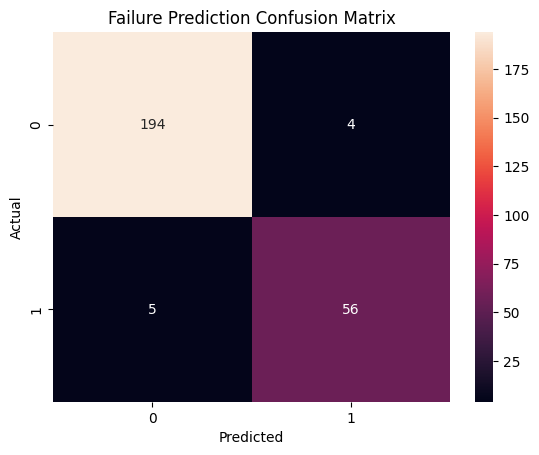

In [66]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = np.where(true_rul2_clipped <= 30, 1, 0)
y_pred = np.where(final_predictions <= 30, 1, 0)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Failure Prediction Confusion Matrix")

plt.show()

In [67]:
import joblib
joblib.dump(xgb_boss, 'xgb_model_fd002.pkl')

joblib.dump(scaler, 'scaler_fd002.pkl')

joblib.dump(kmeans, 'kmeans_fd002.pkl')
joblib.dump(xgb_boss, 'model.pkl', compress=3)

joblib.dump(X_train.columns.tolist(), 'features_fd002.pkl')

print("saved succefully!")

saved succefully!


In [ ]:
# from google.colab import files

#  files.download('xgb_model_fd002.pkl')
#  files.download('scaler_fd002.pkl')
#  files.download('kmeans_fd002.pkl')
#  files.download('features_fd002.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>